In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import ttest_ind

In [2]:
### Fig.3(A)
data9 = pd.read_pickle('G_ripple_data9.pkl')
data9.head(2)

,concept,delta_C_ITE,group,matched_group
0,Physics,0.632150,winner,M4
1,Chemistry,-0.966393,winner,M17


In [3]:
aggregations = {'mean': ('delta_C_ITE', np.mean),
    '95% CI': ('delta_C_ITE', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data9.groupby(["concept", "group"]).agg(**aggregations)
result1.reset_index(inplace=True)
custom_order = ['Mathematics','Physics','Materials science', 'Medicine','Computer science','Biology','Chemistry','Engineering','Environmental science','Geology','Geography','Psychology','Economics','Business','Sociology','Political science','Philosophy','Art','History']
result1['concept'] = pd.Categorical(result1['concept'], categories=custom_order, ordered=True)
result1 = result1.sort_values(by='concept')
result1['index']=[0,0,1,1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,9,9,10,10,11,11,12,12,13,13,14,14,15,15,16,16,17,17,18,18]
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1764041/3993552497.py:3: FutureWarning: The provided callable <function mean at 0x14fa706c2020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data9.groupby(["concept", "group"]).agg(**aggregations)


,concept,group,mean,95% CI,index
25,Mathematics,winner,0.076478,0.009012,0
24,Mathematics,coauthor,0.039485,0.004146,0
30,Physics,coauthor,0.022836,0.001678,1
31,Physics,winner,0.055287,0.005353,1
23,Materials science,winner,0.070660,0.006772,2
22,Materials science,coauthor,0.022204,0.001448,2
27,Medicine,winner,0.062858,0.007579,3
26,Medicine,coauthor,0.028476,0.001025,3
8,Computer science,coauthor,0.032985,0.001593,4
9,Computer science,winner,0.058500,0.007011,4


In [4]:
results = []
for concept, group_df in data9.groupby("concept"):
    g1 = group_df[group_df["group"] == "coauthor"]["delta_C_ITE"].dropna()
    g2 = group_df[group_df["group"] == "winner"]["delta_C_ITE"].dropna()
    t_stat, p_val = ttest_ind(g1, g2, equal_var=False) 
    if p_val < 0.001:
        stars = "***"
    elif p_val < 0.01:
        stars = "**"
    elif p_val < 0.05:
        stars = "*"
    elif p_val < 0.1:
        stars = "."
    else:
        stars = ""
    results.append({"concept": concept,"t_stat": t_stat,"p_value": p_val, "significance": stars })
ttest_result = pd.DataFrame(results)
ttest_result

,concept,t_stat,p_value,significance
0,Art,-1.419444,1.558446e-01,
1,Biology,-7.254240,4.122277e-13,***
2,Business,-2.248432,2.482155e-02,*
3,Chemistry,-4.864760,1.148435e-06,***
4,Computer science,-6.955409,3.636724e-12,***
5,Economics,-1.754844,7.944344e-02,.
6,Engineering,0.213021,8.313407e-01,
7,Environmental science,-2.140868,3.235667e-02,*
8,Geography,3.656184,2.595422e-04,***
9,Geology,-1.252081,2.105912e-01,


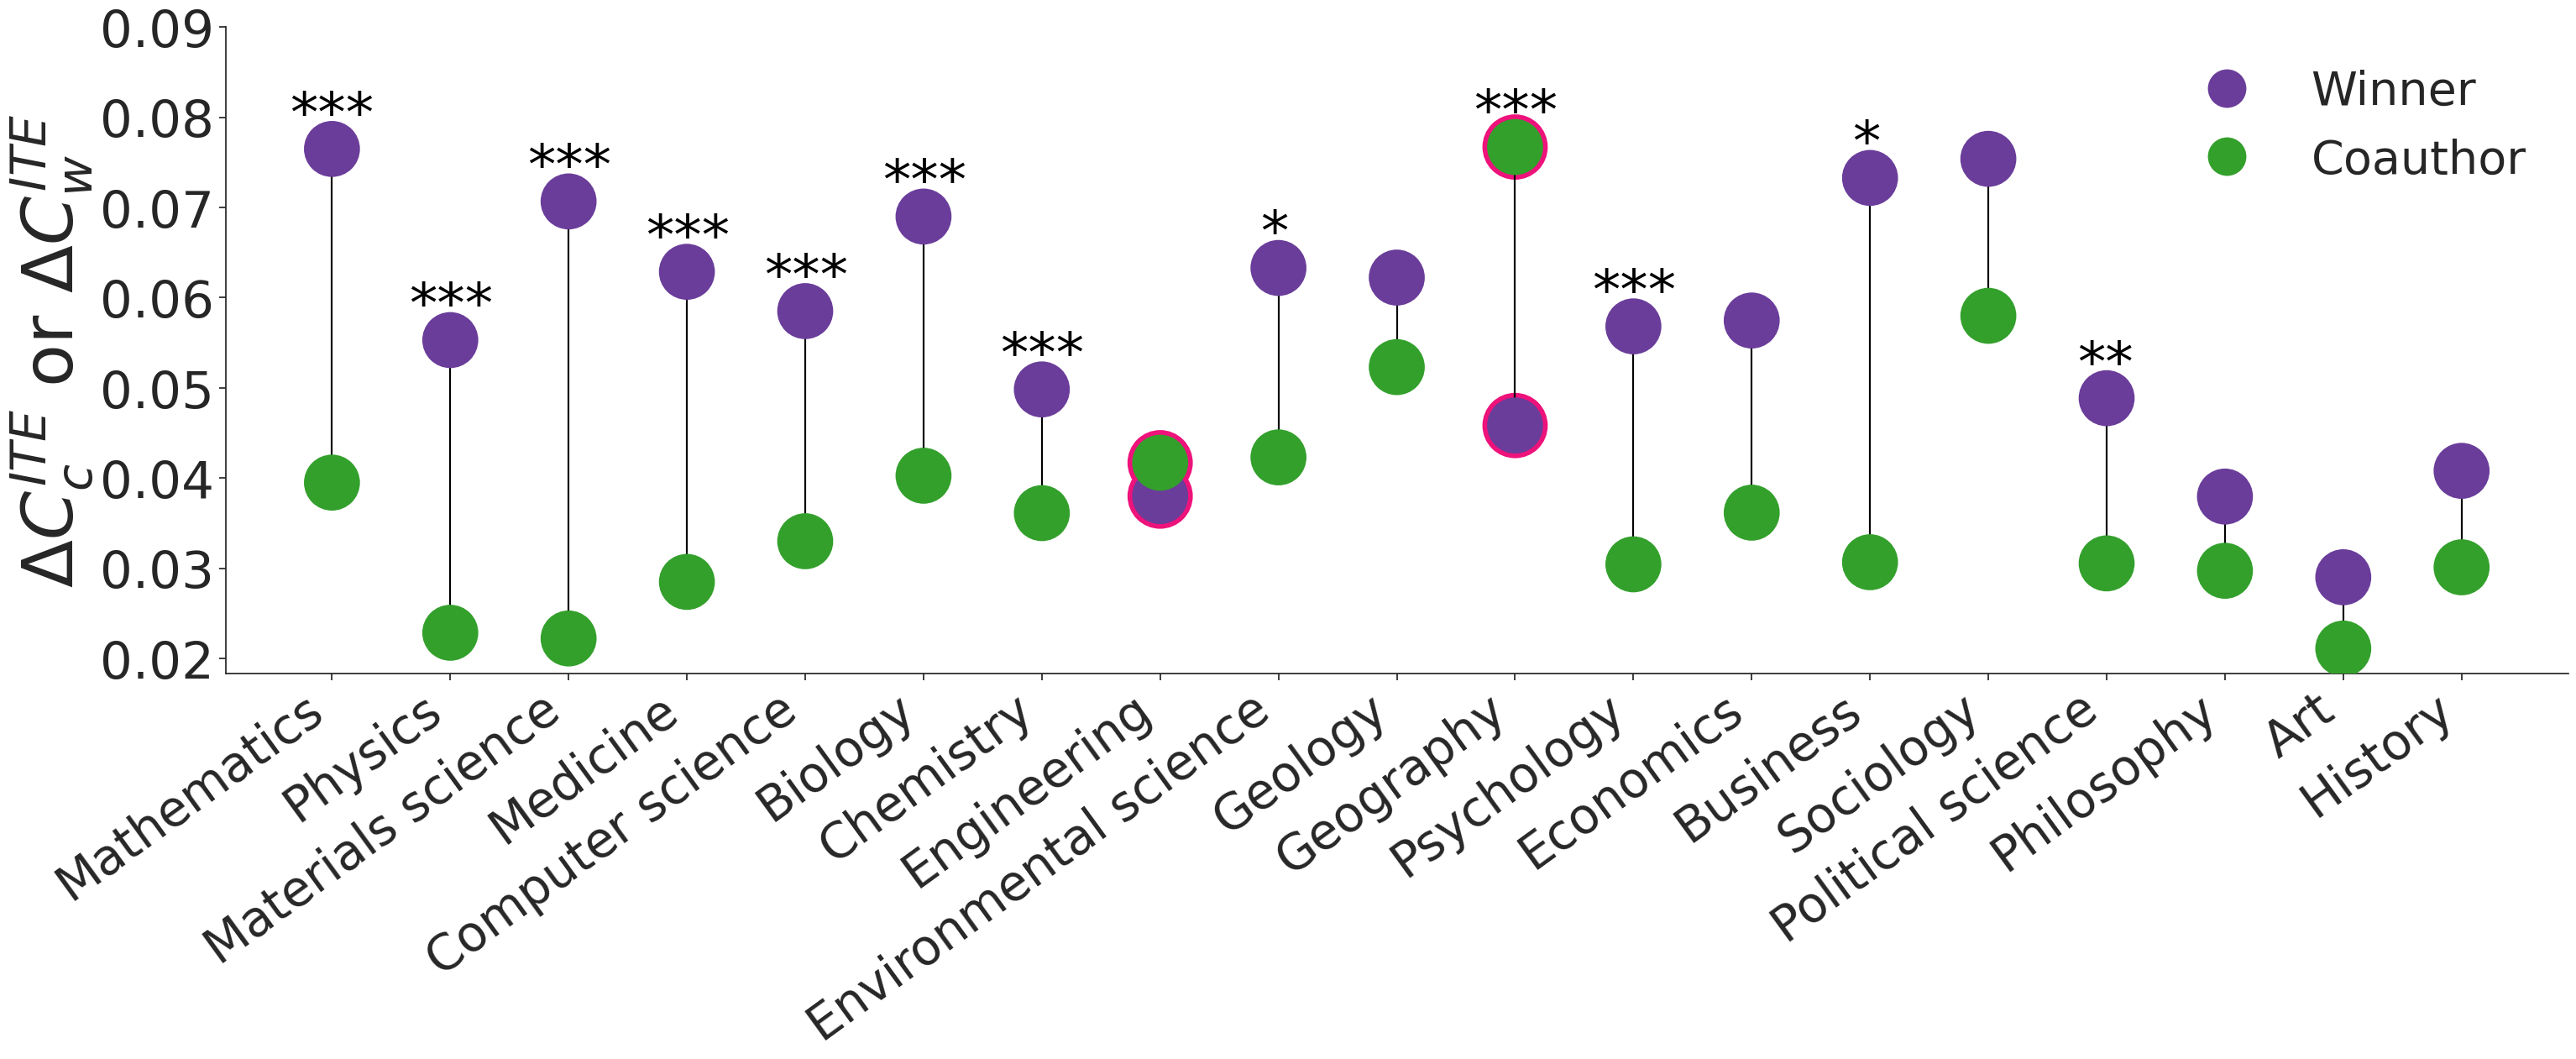

In [5]:
sns.set(font_scale=1.5)
sns.set(style="ticks") 
fig, ax = plt.subplots(figsize=(36, 10))
sns.stripplot(x='index', y='mean', hue='group', data=result1, jitter=0, palette={"winner": "#6A3D9A", "coauthor": "#33A02C"}, size=48, ax=ax)
x_labels = ['Mathematics', 'Physics', 'Materials science', 'Medicine', 'Computer science', 'Biology', 'Chemistry', 'Engineering', 'Environmental science', 'Geology', 'Geography', 'Psychology', 'Economics', 'Business', 'Sociology', 'Political science', 'Philosophy', 'Art', 'History']
x_positions = list(range(len(x_labels)))
plt.xticks(x_positions, x_labels, rotation=36, ha="right",fontsize=42)
plt.yticks(fontsize=44)
## 
for i in result1['index']:
    winner_data = result1[(result1['index'] == i) & (result1['group'] == 'winner')]
    coauthor_data = result1[(result1['index'] == i) & (result1['group'] == 'coauthor')]
    winner_mean = winner_data['mean']
    coauthor_mean = coauthor_data['mean']
    plt.plot([i,i], [winner_mean, coauthor_mean], linestyle='-', linewidth=1.5, color='black')
##
plt.scatter(7, 0.037988, marker='o', s=2600, edgecolors='#EE127B', facecolors='none', zorder=0,linewidths=5)
plt.scatter(7, 0.041688, marker='o', s=2600, edgecolors='#EE127B', facecolors='none', zorder=0,linewidths=5)
plt.scatter(10, 0.045814, marker='o', s=2600, edgecolors='#EE127B', facecolors='none', zorder=0,linewidths=5) # #1180EF #EE127B
plt.scatter(10, 0.076692, marker='o', s=2600, edgecolors='#EE127B', facecolors='none', zorder=0,linewidths=5)
## 
plt.text(-0.36, 0.078478, '***', fontsize=48,color='black')
plt.text(0.65, 0.05728, '***', fontsize=48,color='black')
plt.text(1.65, 0.07266, '***', fontsize=48,color='black')
plt.text(2.65, 0.064858, '***', fontsize=48,color='black')
plt.text(3.65, 0.0605, '***', fontsize=48,color='black')
plt.text(4.65, 0.070983, '***', fontsize=48,color='black')
plt.text(5.65, 0.051816, '***', fontsize=48,color='black')
plt.text(7.85, 0.065283, '*', fontsize=48,color='black',zorder=1)
plt.text(9.65, 0.078692, '***', fontsize=48,color='black')
plt.text(10.65, 0.058807, '***', fontsize=48,color='black')
plt.text(12.85, 0.075266, '*', fontsize=48,color='black')
plt.text(14.75, 0.050846, '**', fontsize=48,color='black')
legend = plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Winner', markerfacecolor='#6A3D9A', markersize=34),
                            plt.Line2D([0], [0], marker='o', color='w', label='Coauthor', markerfacecolor='#33A02C', markersize=34)],
                   loc='upper right', fontsize=40, bbox_to_anchor=(1, 1.0),frameon=False, facecolor='none',framealpha=0)  
legend.get_frame().set_edgecolor('none')
plt.ylim(None,0.09)
plt.xlabel('')
plt.ylabel(r"$\Delta C^{ITE}_{c}$ or $\Delta C^{ITE}_{w}$",fontsize=60)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [6]:
### Fig.3(B)
data10 = pd.read_pickle('G_ripple_data10.pkl')
data10.head(2)

,award_year,group,delta_C_ITE
0,1969,coauthor,0.104929
1,1969,winner,0.155128


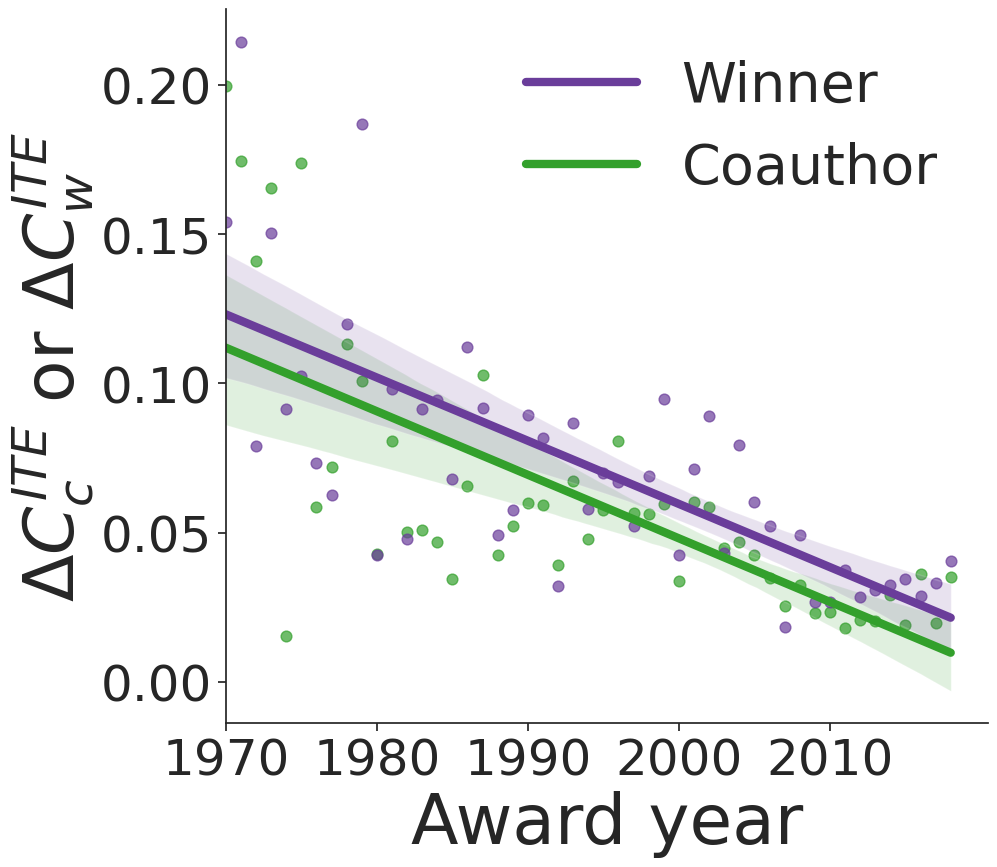

In [7]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
ax.set_facecolor('white') 
color_mapping = {'winner': '#6A3D9A', 'coauthor': '#33A02C'}
sns.lmplot(x='award_year', y='delta_C_ITE', data=data10, hue='group', ci=95, order=1,palette=color_mapping,legend=False,scatter_kws={"alpha": 0.7, "s": 60}, line_kws={"linewidth": 6},height=8,aspect=1.1)
plt.legend(loc='upper right', fontsize=40,frameon=False)
line_winner = plt.Line2D([0], [0], color=color_mapping['winner'], linewidth=6)
line_coauthor = plt.Line2D([0], [0], color=color_mapping['coauthor'], linewidth=6)
plt.legend([line_winner, line_coauthor], ['Winner', 'Coauthor'], loc='upper right', fontsize=40, frameon=False,bbox_to_anchor=(1, 1.0))
plt.xlabel('Award year',fontsize=50)
plt.ylabel(r"$\Delta C^{ITE}_{c}$ or $\Delta C^{ITE}_{w}$",fontsize=50)
plt.xlim(1970, None)
plt.xticks(range(1970, 2020,10),fontsize=36)
plt.yticks(fontsize=36)
plt.show()

In [9]:
### Fig.3(C)
data11 = pd.read_pickle('G_ripple_data11.pkl')
data11.head(2)

,delta_T,group,delta_C_ITE
0,1,coauthor,0.179030
1,1,winner,0.350124


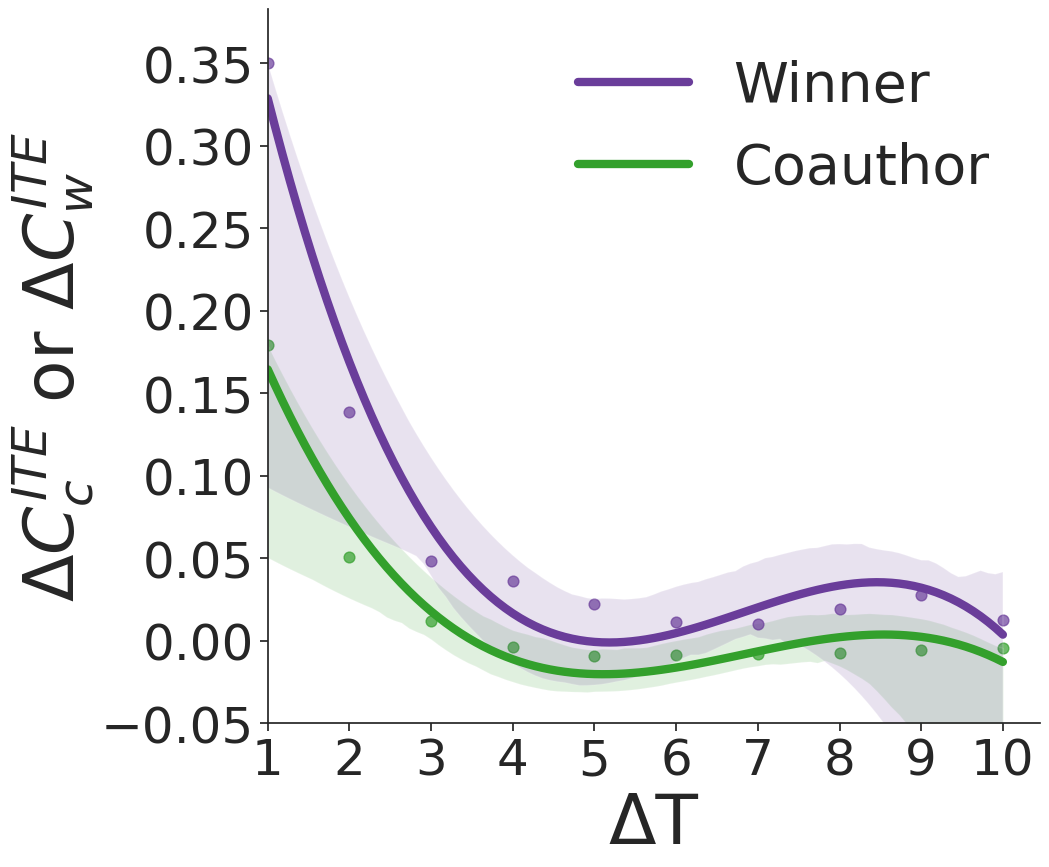

In [10]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
color_mapping = {'winner': '#6A3D9A', 'coauthor': '#33A02C'}
sns.lmplot(x='delta_T', y='delta_C_ITE', data=data11, hue='group', ci=95, order=3,palette=color_mapping,legend=False,scatter_kws={"alpha": 0.7, "s": 60}, line_kws={"linewidth": 6},height=8,aspect=1.1)
plt.ylim(-0.05, None)
plt.xlim(1, None)
plt.xticks(range(1, 11))
plt.legend(loc='upper right', fontsize=40,frameon=False)
line_winner = plt.Line2D([0], [0], color=color_mapping['winner'], linewidth=6)
line_coauthor = plt.Line2D([0], [0], color=color_mapping['coauthor'], linewidth=6)
plt.legend([line_winner, line_coauthor], ['Winner', 'Coauthor'], loc='upper right', fontsize=40, frameon=False,bbox_to_anchor=(1, 1.0))
plt.xlabel('ΔT',fontsize=50)
plt.ylabel(r"$\Delta C^{ITE}_{c}$ or $\Delta C^{ITE}_{w}$",fontsize=50)
plt.xticks(fontsize=36)
plt.yticks(fontsize=36)
plt.show()

In [11]:
### Fig.3(D)
data12 = pd.read_pickle('G_ripple_data12.pkl')
data12.head(2)

,Award age,group,delta_C_ITE
0,22,coauthor,-0.003624
1,22,winner,0.379220


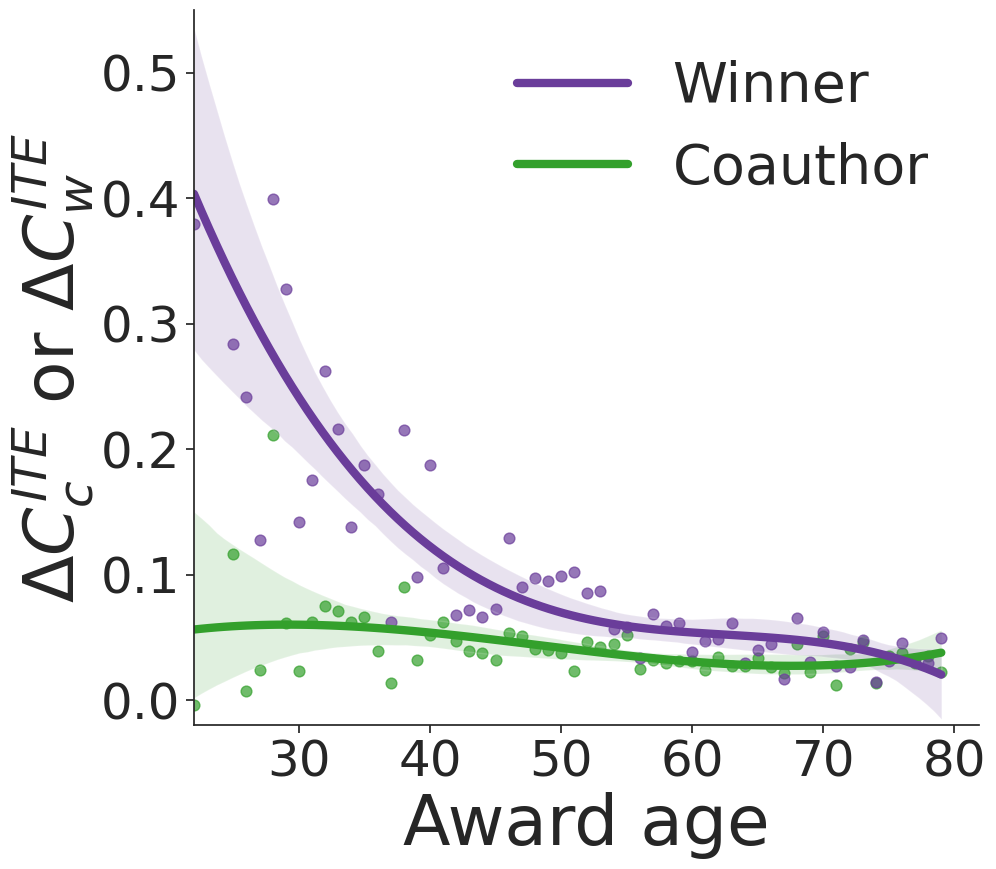

In [12]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
color_mapping = {'winner': '#6A3D9A', 'coauthor': '#33A02C'}
sns.lmplot(x='Award age', y='delta_C_ITE', data=data12, hue='group', ci=95, order=3,palette=color_mapping,legend=False,scatter_kws={"alpha": 0.7, "s": 60}, line_kws={"linewidth": 6},height=8,aspect=1.1)
plt.ylim(-0.02, 0.55)
plt.legend(loc='upper right', fontsize=40,frameon=False)
line_winner = plt.Line2D([0], [0], color=color_mapping['winner'], linewidth=6)
line_coauthor = plt.Line2D([0], [0], color=color_mapping['coauthor'], linewidth=6)
plt.legend([line_winner, line_coauthor], ['Winner', 'Coauthor'], loc='upper right', fontsize=40, frameon=False,bbox_to_anchor=(1, 1.0))
plt.xlabel('Award age',fontsize=50)
plt.ylabel(r"$\Delta C^{ITE}_{c}$ or $\Delta C^{ITE}_{w}$",fontsize=50)
plt.xlim(22, None)
plt.xticks(range(30, 81,10),fontsize=36)
plt.yticks(fontsize=36)
plt.show()

In [13]:
### Fig.3(E)
data13 = pd.read_pickle('G_ripple_data13.pkl')
data13.head(2)

,WinnerID,genderLabel,matched_group,delta_C_ITE,group
0,W3306,male,M4,0.632150,winner
1,W3218,male,M17,-0.966393,winner


In [14]:
aggregations = {'mean': ('delta_C_ITE', np.mean),
    '95% CI': ('delta_C_ITE', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result13 = data13.groupby(["genderLabel", "group"]).agg(**aggregations)
result13.reset_index(inplace=True)
result13

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1764041/2068231493.py:3: FutureWarning: The provided callable <function mean at 0x14fa706c2020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result13 = data13.groupby(["genderLabel", "group"]).agg(**aggregations)


,genderLabel,group,mean,95% CI
0,female,coauthor,0.038752,0.001585
1,female,winner,0.063898,0.007915
2,male,coauthor,0.030866,0.000626
3,male,winner,0.059077,0.002404


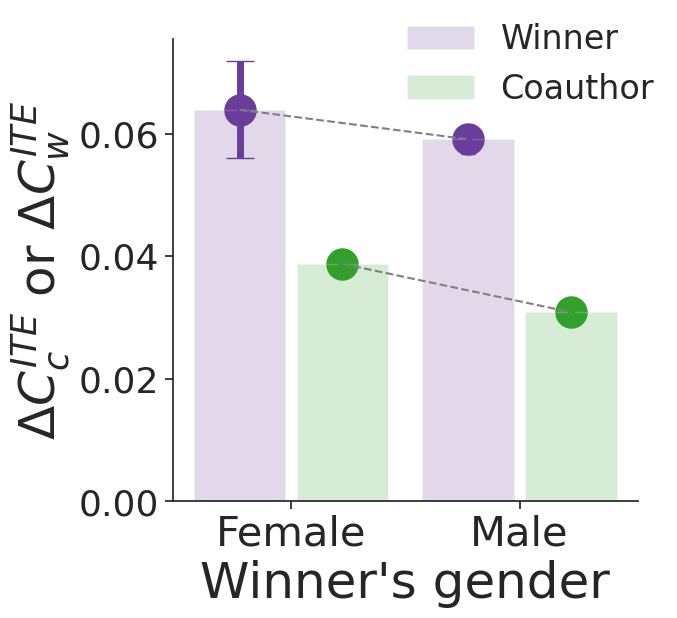

In [15]:
fig, ax = plt.subplots(figsize=(6,6))
x=np.arange(2)
y1=[0.063898,0.059077] #winner
y2=[0.038752,0.030866] #coauthor
bar_width=0.4
gap_width = 0.05
tick_label=['Female','Male']
bars1=ax.bar(x, y1, bar_width, color="#6A3D9A", align="center", label='Winner', alpha=0.2)
bars2=ax.bar(x + bar_width+ gap_width, y2, bar_width, color="#33A02C", label="Coauthor", alpha=0.2)

ax.scatter(0.45, 0.038752, marker='o', s=500, edgecolors='#33A02C', facecolors='#33A02C', zorder=0)
ax.errorbar(0.45, 0.038752, yerr=0.001585, color='#33A02C', capsize=5,elinewidth=5)
ax.scatter(1.45, 0.030866, marker='o', s=500, edgecolors='#33A02C', facecolors='#33A02C', zorder=0)
ax.errorbar(1.45, 0.030866, yerr=0.000626, color='#33A02C', capsize=5,elinewidth=5)
ax.plot([0.45, 1.45], [0.038752, 0.030866], linestyle='--', color='gray')

ax.scatter(0, 0.063898, marker='o', s=500, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=0)
ax.errorbar(0, 0.063898, yerr=0.007915, color='#6A3D9A', capsize=10,elinewidth=5)
ax.scatter(1, 0.059077, marker='o', s=500, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=0)
ax.errorbar(1, 0.059077, yerr=0.002404, color='#6A3D9A', capsize=5,elinewidth=5)
ax.plot([0, 1], [0.063898, 0.059077], linestyle='--', color='gray')

ax.set_xlabel("Winner's gender", fontsize=36)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$ or $\Delta C^{ITE}_{w}$", fontsize=36)
ax.set_xticks(x + (bar_width + gap_width) / 2)
ax.set_xticklabels(tick_label, fontsize=30)
ax.tick_params(axis='y', labelsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend = ax.legend(fontsize=24, loc='upper right', bbox_to_anchor=(1.1, 1.1),frameon=False, facecolor='none',framealpha=0) 
legend.get_frame().set_edgecolor('none')
plt.show()

In [16]:
### Fig.3(F)
data14 = pd.read_pickle('G_ripple_data14.pkl')
data14.head(2)

,WinnerID,awardLabel,award_prestige,is_top5,prestige_group,matched_group,delta_C_ITE,group
0,W3190,Dannie Heineman Prize for Mathematical Physics,894.033333,0,High,M4,0.632150,winner
1,W1090,Dannie Heineman Prize for Mathematical Physics,894.033333,0,High,M6530,-0.201173,winner


In [17]:
aggregations = {'mean': ('delta_C_ITE', np.mean),
    '95% CI': ('delta_C_ITE', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data14.groupby(["prestige_group", "group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1764041/4099449801.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1 = data14.groupby(["prestige_group", "group"]).agg(**aggregations)
/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1764041/4099449801.py:3: FutureWarning: The provided callable <function mean at 0x14fa706c2020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data14.groupby(["prestige_group", "group"]).agg(**aggregations)


,prestige_group,group,mean,95% CI
0,Low,coauthor,0.034231,0.000847
1,Low,winner,0.062549,0.003196
2,High,coauthor,0.029330,0.000831
3,High,winner,0.056028,0.003413


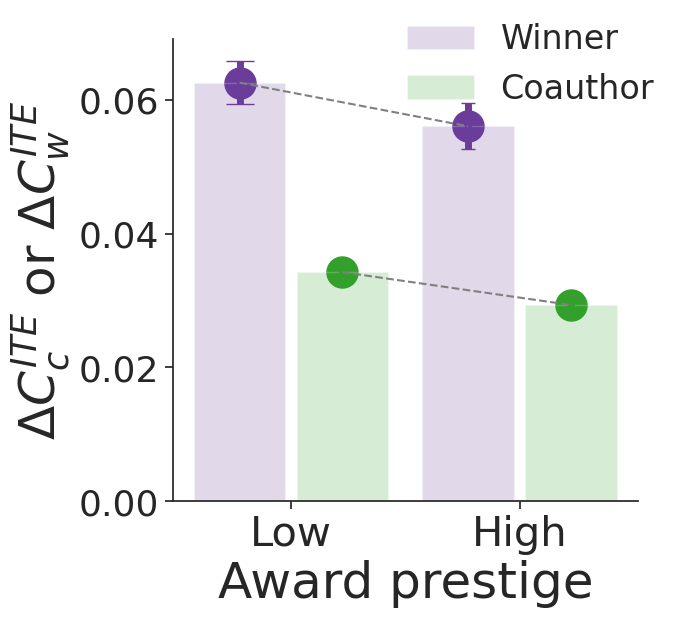

In [18]:
fig, ax = plt.subplots(figsize=(6,6))
x=np.arange(2)
y1=[0.062549,0.056028] #winner
y2=[0.034231,0.029330] #coauthor
bar_width=0.4
gap_width = 0.05
tick_label=['Low','High']
bars1=ax.bar(x, y1, bar_width, color="#6A3D9A", align="center", label='Winner', alpha=0.2)
bars2=ax.bar(x + bar_width+ gap_width, y2, bar_width, color="#33A02C", label="Coauthor", alpha=0.2)
##mean& error bar coauthor
ax.scatter(0.45, 0.034231, marker='o', s=500, edgecolors='#33A02C', facecolors='#33A02C', zorder=0)
ax.errorbar(0.45, 0.034231, yerr=0.000847, color='#33A02C', capsize=5,elinewidth=5)
ax.scatter(1.45, 0.029330, marker='o', s=500, edgecolors='#33A02C', facecolors='#33A02C', zorder=0)
ax.errorbar(1.45, 0.029330, yerr=0.000831, color='#33A02C', capsize=5,elinewidth=5)
ax.plot([0.45, 1.45], [0.034231, 0.029330], linestyle='--', color='gray')
##### winner
ax.scatter(0, 0.062549, marker='o', s=500, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=0)
ax.errorbar(0, 0.062549, yerr=0.003196, color='#6A3D9A', capsize=10,elinewidth=5)
ax.scatter(1, 0.056028, marker='o', s=500, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=0)
ax.errorbar(1, 0.056028, yerr=0.003413, color='#6A3D9A', capsize=5,elinewidth=5)
ax.plot([0, 1], [0.062549, 0.056028], linestyle='--', color='gray')

ax.set_xlabel('Award prestige', fontsize=36)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$ or $\Delta C^{ITE}_{w}$", fontsize=36)
ax.set_xticks(x + (bar_width + gap_width) / 2)
ax.set_xticklabels(tick_label, fontsize=30)
ax.tick_params(axis='y', labelsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend = ax.legend(fontsize=24, loc='upper right', bbox_to_anchor=(1.1, 1.1),frameon=False, facecolor='none',framealpha=0) 
legend.get_frame().set_edgecolor('none')
plt.show()

In [19]:
### Fig.3(G)
aggregations = {'mean': ('delta_C_ITE', np.mean),
    '95% CI': ('delta_C_ITE', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data14.groupby(["is_top5", "group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1764041/1425778624.py:4: FutureWarning: The provided callable <function mean at 0x14fa706c2020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data14.groupby(["is_top5", "group"]).agg(**aggregations)


,is_top5,group,mean,95% CI
0,0,coauthor,0.032098,0.000685
1,0,winner,0.060371,0.002624
2,1,coauthor,0.031038,0.001189
3,1,winner,0.056751,0.005115


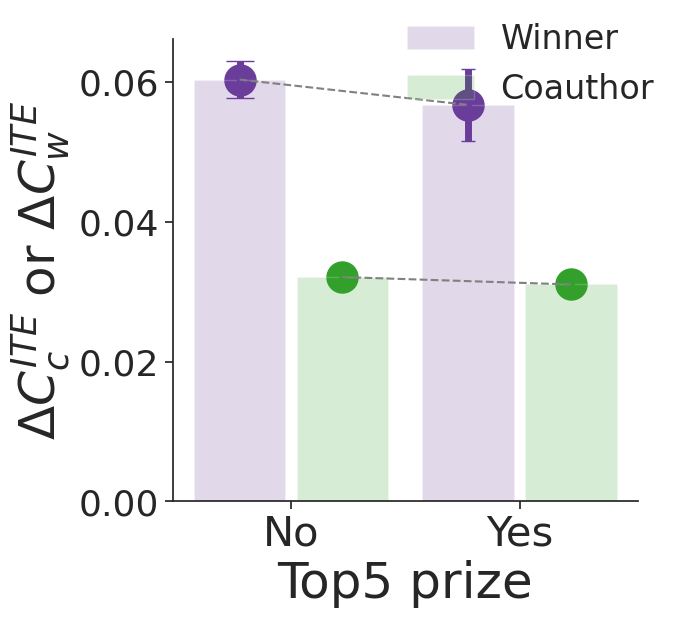

In [20]:
fig, ax = plt.subplots(figsize=(6,6))
x=np.arange(2)
y1=[0.060371,0.056751] #winner
y2=[0.032098,0.031038] #coauthor
bar_width=0.4
gap_width = 0.05
tick_label=['No','Yes']
bars1=ax.bar(x, y1, bar_width, color="#6A3D9A", align="center", label='Winner', alpha=0.2)
bars2=ax.bar(x + bar_width+ gap_width, y2, bar_width, color="#33A02C", label="Coauthor", alpha=0.2)
##mean& error bar coauthor
ax.scatter(0.45, 0.032098, marker='o', s=500, edgecolors='#33A02C', facecolors='#33A02C', zorder=0)
ax.errorbar(0.45, 0.032098, yerr=0.000685, color='#33A02C', capsize=5,elinewidth=5)
ax.scatter(1.45, 0.031038, marker='o', s=500, edgecolors='#33A02C', facecolors='#33A02C', zorder=0)
ax.errorbar(1.45, 0.031038, yerr=0.001189, color='#33A02C', capsize=5,elinewidth=5)
ax.plot([0.45, 1.45], [0.032098, 0.031038], linestyle='--', color='gray')
##### winner
ax.scatter(0, 0.060371, marker='o', s=500, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=0)
ax.errorbar(0, 0.060371, yerr=0.002624, color='#6A3D9A', capsize=10,elinewidth=5)
ax.scatter(1, 0.056751, marker='o', s=500, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=0)
ax.errorbar(1, 0.056751, yerr=0.005115, color='#6A3D9A', capsize=5,elinewidth=5)
ax.plot([0, 1], [0.060371, 0.056751], linestyle='--', color='gray')
###
ax.set_xlabel('Top5 prize', fontsize=36)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$ or $\Delta C^{ITE}_{w}$", fontsize=36)
ax.set_xticks(x + (bar_width + gap_width) / 2)
ax.set_xticklabels(tick_label, fontsize=30)
ax.tick_params(axis='y', labelsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend = ax.legend(fontsize=24, loc='upper right', bbox_to_anchor=(1.1, 1.1),frameon=False, facecolor='none',framealpha=0) 
legend.get_frame().set_edgecolor('none')
plt.show()